In [251]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [252]:
df = pd.read_csv("dataset.csv")

In [253]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [254]:
df.head()
df = df.drop(columns=["customerID"],axis=1)

In [255]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler


le = LabelEncoder()


binary_cols = ["Churn","Dependents","Partner","PaperlessBilling","gender","PhoneService"]
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [256]:
df.head()
ohe = OneHotEncoder()


one_hot_cols = ["MultipleLines","InternetService","OnlineSecurity","DeviceProtection","TechSupport","StreamingTV","StreamingMovies","Contract","PaymentMethod","OnlineBackup"]

encoded_cols = ohe.fit_transform(
    df[one_hot_cols]
)

encoded_df = pd.DataFrame(
    encoded_cols.toarray(),
    columns=ohe.get_feature_names_out(),
    index=df.index
)
df_new = pd.concat([df.drop(columns=one_hot_cols),encoded_df],axis=1)

df_new.shape


(7043, 41)

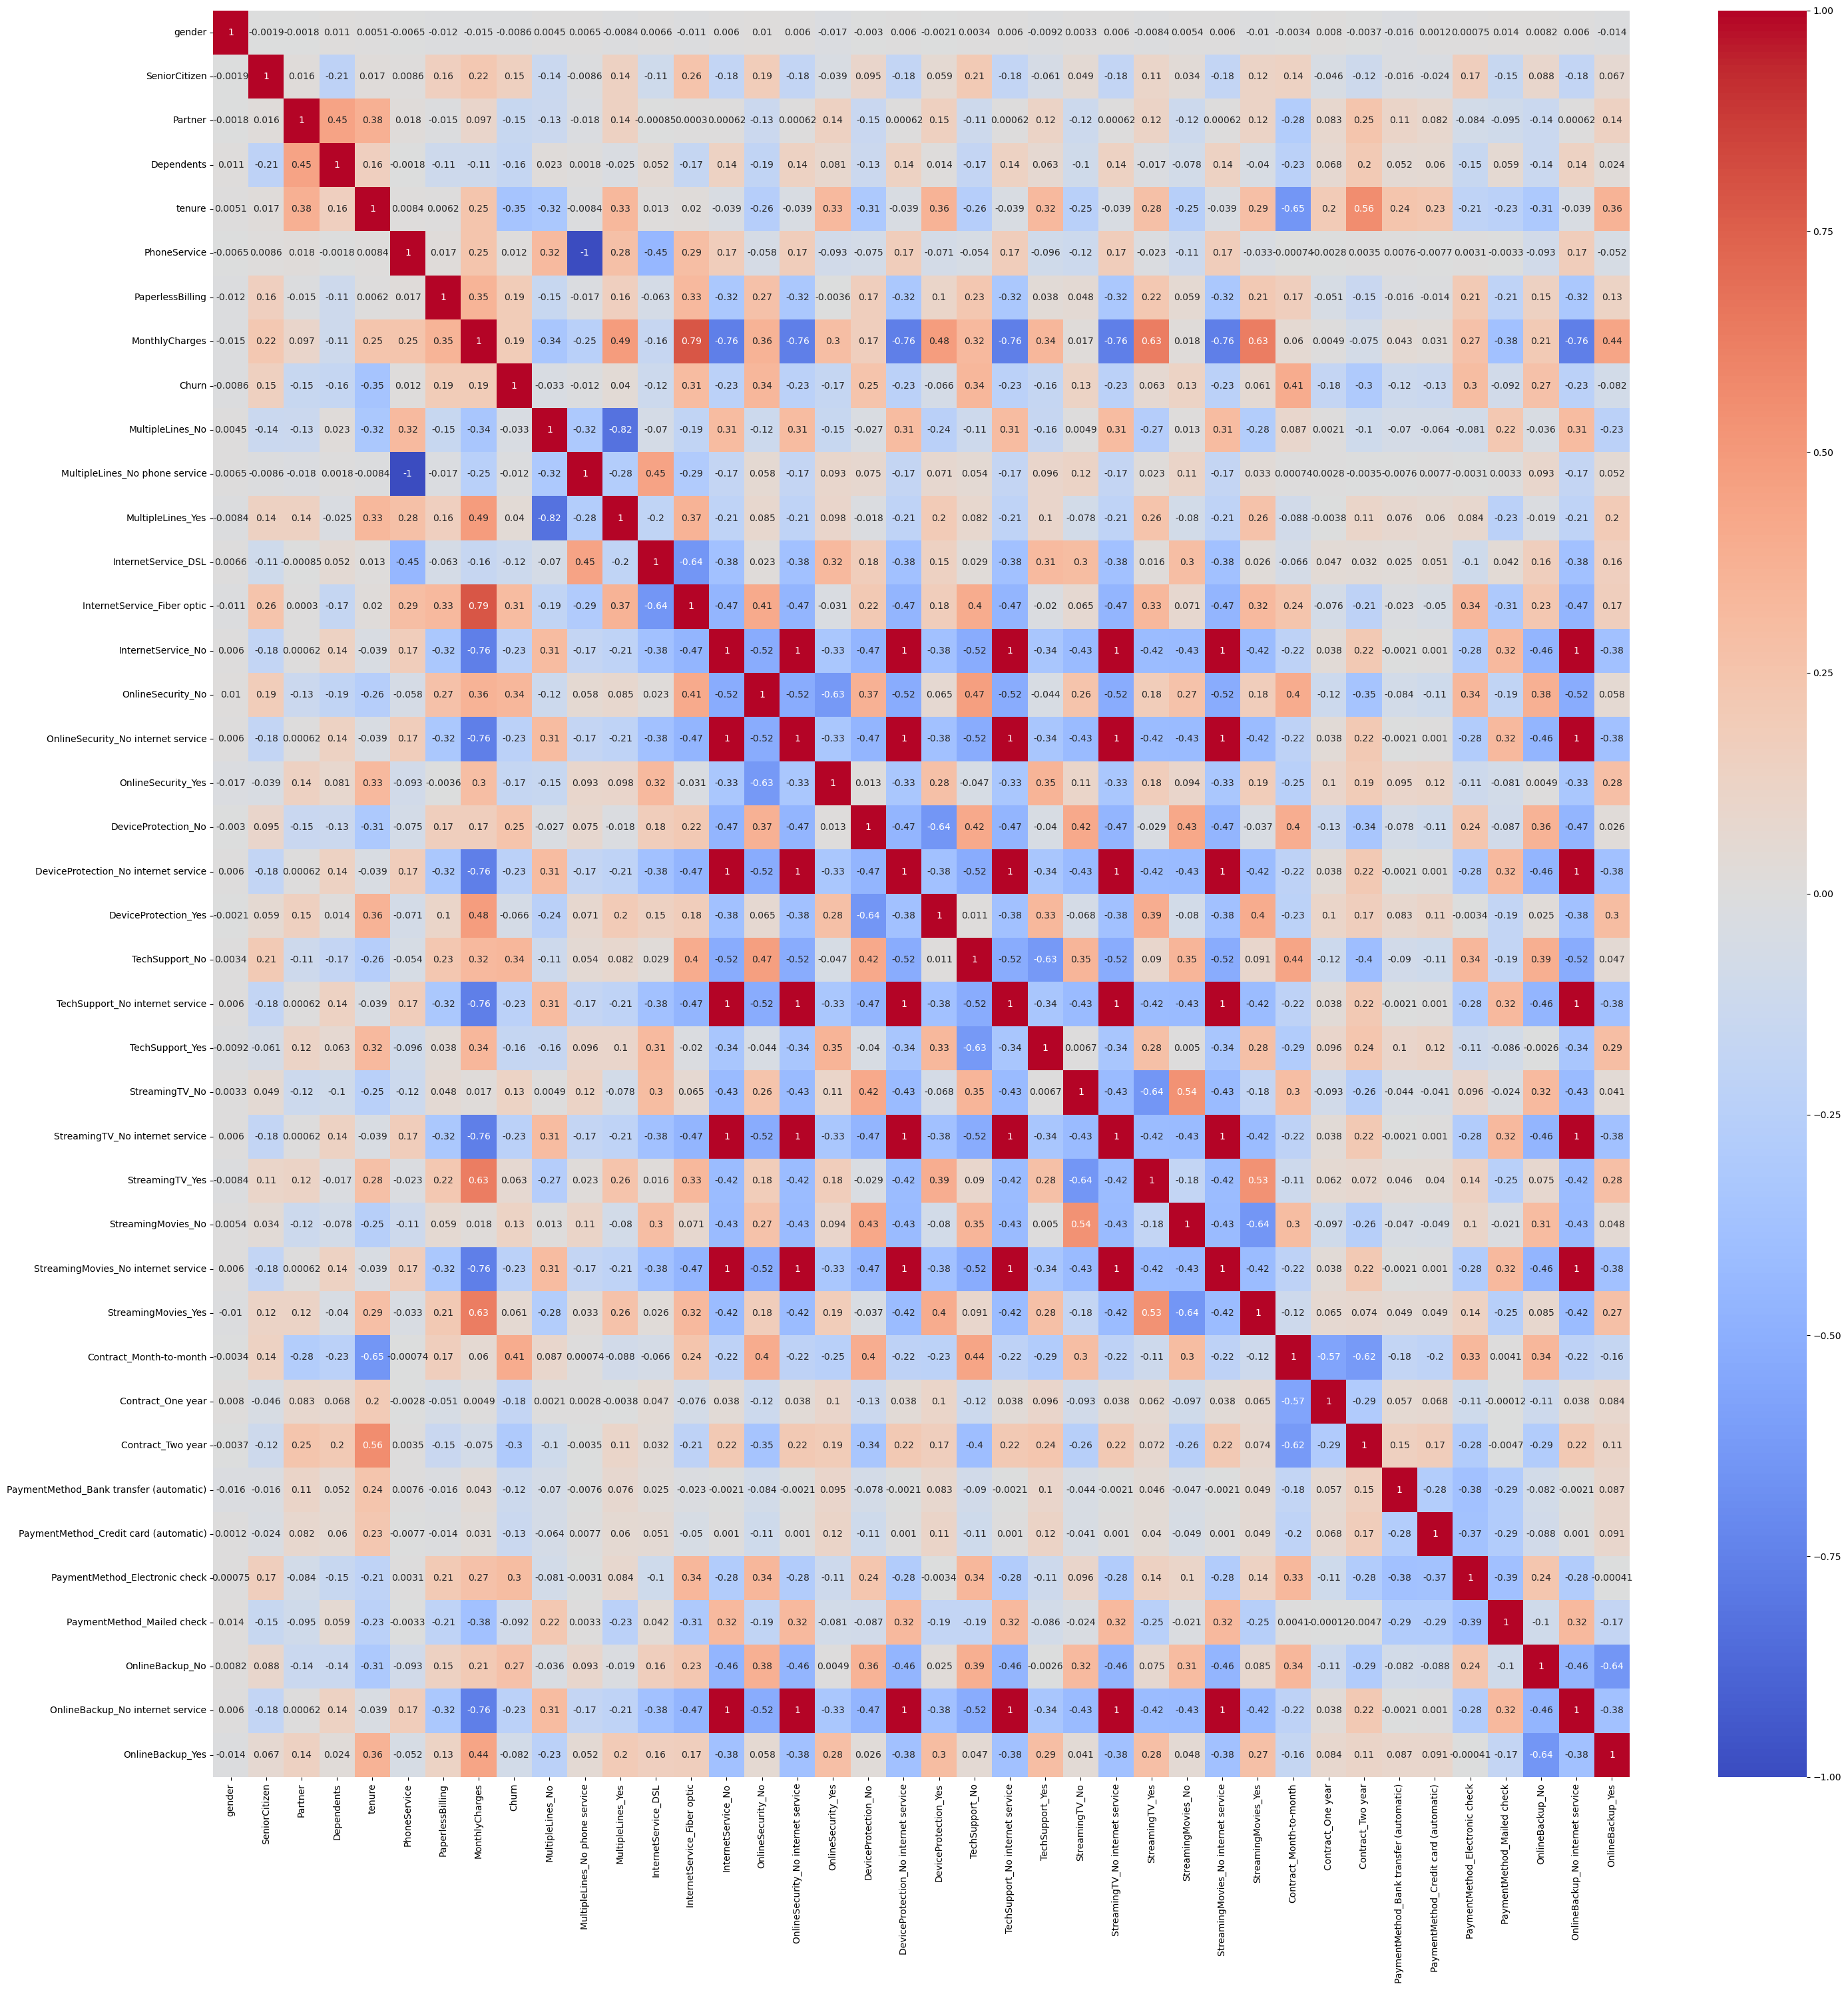

In [257]:
plt.figure(figsize=(30,30))

sns.heatmap(
    df_new.select_dtypes(include="number").corr(),

    annot=True,
    cmap="coolwarm"
)

plt.tight_layout()



In [258]:
df_new.select_dtypes(include="number").corr()["Churn"].sort_values(ascending=False)


Churn                                      1.000000
Contract_Month-to-month                    0.405103
OnlineSecurity_No                          0.342637
TechSupport_No                             0.337281
InternetService_Fiber optic                0.308020
PaymentMethod_Electronic check             0.301919
OnlineBackup_No                            0.268005
DeviceProtection_No                        0.252481
MonthlyCharges                             0.193356
PaperlessBilling                           0.191825
SeniorCitizen                              0.150889
StreamingMovies_No                         0.130845
StreamingTV_No                             0.128916
StreamingTV_Yes                            0.063228
StreamingMovies_Yes                        0.061382
MultipleLines_Yes                          0.040102
PhoneService                               0.011942
gender                                    -0.008612
MultipleLines_No phone service            -0.011942
MultipleLine

In [259]:
df_new["TotalCharges"] = pd.to_numeric(df_new["TotalCharges"],errors="coerce")

df_new = df_new.dropna()
df_new["TotalCharges"] = df_new["MonthlyCharges"] * df["tenure"]

"""
Tweaking these for better accuracy
"""
# df_new["ChargesPerMonth"] = df_new["TotalCharges"] / (df_new["tenure"] + 1)

df_new = df_new.drop(columns=["MonthlyCharges","tenure"])

In [260]:
from sklearn.model_selection import train_test_split

X = df_new.drop(columns=["Churn"],axis=1)
Y = df_new["Churn"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
)

In [261]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [262]:
import torch 
import torch.nn as nn
from torch.utils.data import TensorDataset,DataLoader
import torch.optim as optim

X_train_tensor = torch.tensor(
    X_train_scaled,dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,dtype=torch.float32
)

Y_train_tensor = torch.tensor(
    Y_train.values,dtype=torch.float32
).view(-1,1)

Y_test_tensor = torch.tensor(
    Y_test.values,dtype=torch.float32
).view(-1,1)


In [263]:
train_dataset = TensorDataset(
    X_train_tensor,
    Y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    Y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32
)

### Deep Learning

In [264]:
class ChurnPredictor(nn.Module):
    
    def __init__(self):
        super(ChurnPredictor,self).__init__()

        self.model = nn.Sequential(
            nn.Linear(
                in_features=X_train.shape[1],
                out_features=64
            ),
            nn.ReLU(),

            nn.Linear(
                in_features=64,
                out_features=32
            ),

            nn.ReLU(),

            nn.Linear(
                in_features=32,
                out_features=16
            ),

            nn.ReLU(),

            nn.Linear(
                in_features=16,
                out_features=1
            ),
        )

    def forward(self,x):
        return self.model(x)

In [ ]:
model = ChurnPredictor()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(params=model.parameters())

In [266]:
epochs =100


best_model_loss = float("inf")
for epoch in range(epochs):
    model.train()

    running_loss = 0.0

    for xb,yb in train_loader:
        optimizer.zero_grad()

        labels = model(xb)

        loss = criterion(labels,yb)
        
        loss.backward()
        optimizer.step()

        running_loss+=loss.item()

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # Telling torch not to compute any gradients
        for xb,yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs,yb)
            running_val_loss +=loss.item()

    epoch_val_loss = running_val_loss/len(test_loader)
    if(epoch_val_loss<best_model_loss):
        best_model_loss = epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt")
    print(f"Epoch : {epoch+1}/{epochs} || Loss: {running_loss}")

Epoch : 1/100 || Loss: 84.87286831438541
Epoch : 2/100 || Loss: 75.05603857338428
Epoch : 3/100 || Loss: 73.40309381484985
Epoch : 4/100 || Loss: 72.70191469788551
Epoch : 5/100 || Loss: 71.7489562034607
Epoch : 6/100 || Loss: 71.5796076208353
Epoch : 7/100 || Loss: 70.57691295444965
Epoch : 8/100 || Loss: 70.11406190693378
Epoch : 9/100 || Loss: 69.54912734031677
Epoch : 10/100 || Loss: 69.24928940832615
Epoch : 11/100 || Loss: 68.83045095205307
Epoch : 12/100 || Loss: 68.40401430428028
Epoch : 13/100 || Loss: 67.86548751592636
Epoch : 14/100 || Loss: 67.0096066147089
Epoch : 15/100 || Loss: 66.53216071426868
Epoch : 16/100 || Loss: 66.11305895447731
Epoch : 17/100 || Loss: 65.69927829504013
Epoch : 18/100 || Loss: 64.83004753291607
Epoch : 19/100 || Loss: 64.44211839139462
Epoch : 20/100 || Loss: 63.38005414605141
Epoch : 21/100 || Loss: 62.9196141064167
Epoch : 22/100 || Loss: 62.12144662439823
Epoch : 23/100 || Loss: 61.025562167167664
Epoch : 24/100 || Loss: 60.77087478339672
Epoc

In [267]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [268]:
model.eval()
with torch.no_grad():
    Y_train_pred = torch.sigmoid(model(X_train_tensor))
    Y_test_pred = torch.sigmoid(model(X_test_tensor))

    train_mse_loss = criterion(Y_train_pred,Y_train_tensor)
    test_mse_loss = criterion(Y_test_pred,Y_test_tensor)

print(f"Training MSE: {train_mse_loss.item()} || Testing MSE: {test_mse_loss.item()}")

Training MSE: 0.7077996730804443 || Testing MSE: 0.7157917022705078


In [269]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

Y_train_pred= (Y_train_pred>0.4).int()
Y_test_pred= (Y_test_pred>0.4).int()
print("Train:",classification_report(Y_train_tensor,Y_train_pred))
print("Test:",classification_report(Y_test_tensor,Y_test_pred))

Train:               precision    recall  f1-score   support

         0.0       0.87      0.87      0.87      4130
         1.0       0.64      0.64      0.64      1495

    accuracy                           0.81      5625
   macro avg       0.76      0.76      0.76      5625
weighted avg       0.81      0.81      0.81      5625

Test:               precision    recall  f1-score   support

         0.0       0.85      0.85      0.85      1033
         1.0       0.58      0.59      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



In [270]:
confusion_matrix(Y_test_tensor,Y_test_pred)

array([[874, 159],
       [153, 221]], dtype=int64)

In [271]:
print("Train:",accuracy_score(Y_train_tensor,Y_train_pred))
print("Test:",accuracy_score(Y_test_tensor,Y_test_pred))

Train: 0.8097777777777778
Test: 0.7782515991471215


In [272]:
import shap
model.eval()
X_train_df = pd.DataFrame(X_train, columns=df_new.drop(columns="Churn").columns)
X_test_df = pd.DataFrame(X_test, columns=df_new.drop(columns="Churn").columns)
model.eval()
explainer = shap.Explainer(
    lambda x: torch.sigmoid(model(torch.tensor(x.values).float())).detach().numpy(),
    X_train_df
)

shap_values = explainer(X_test_df)


PermutationExplainer explainer: 1408it [00:23, 32.08it/s]                          


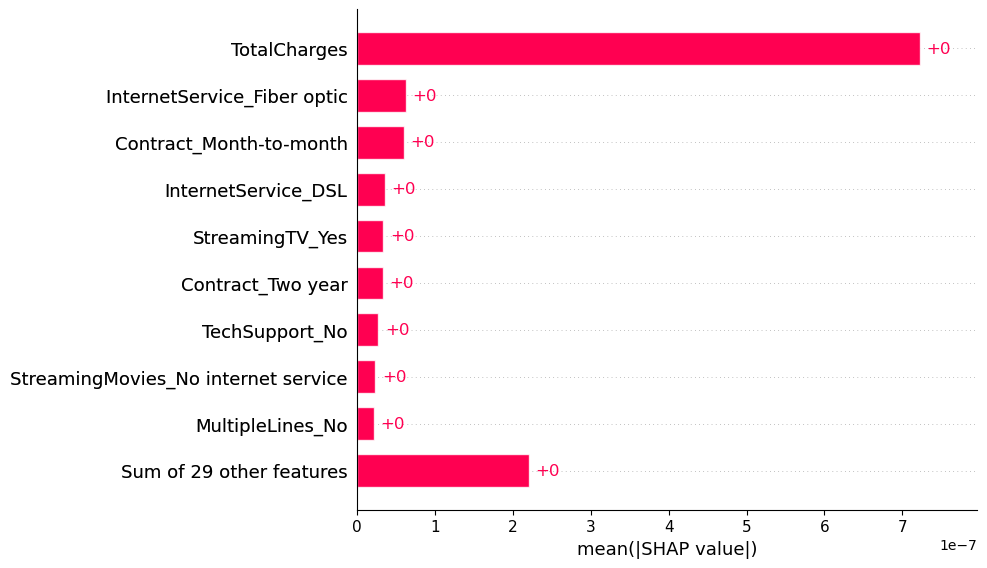

In [273]:
shap.plots.bar(shap_values)

C:\Users\Asus\AppData\Local\Temp\ipykernel_3752\1452734491.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_df)


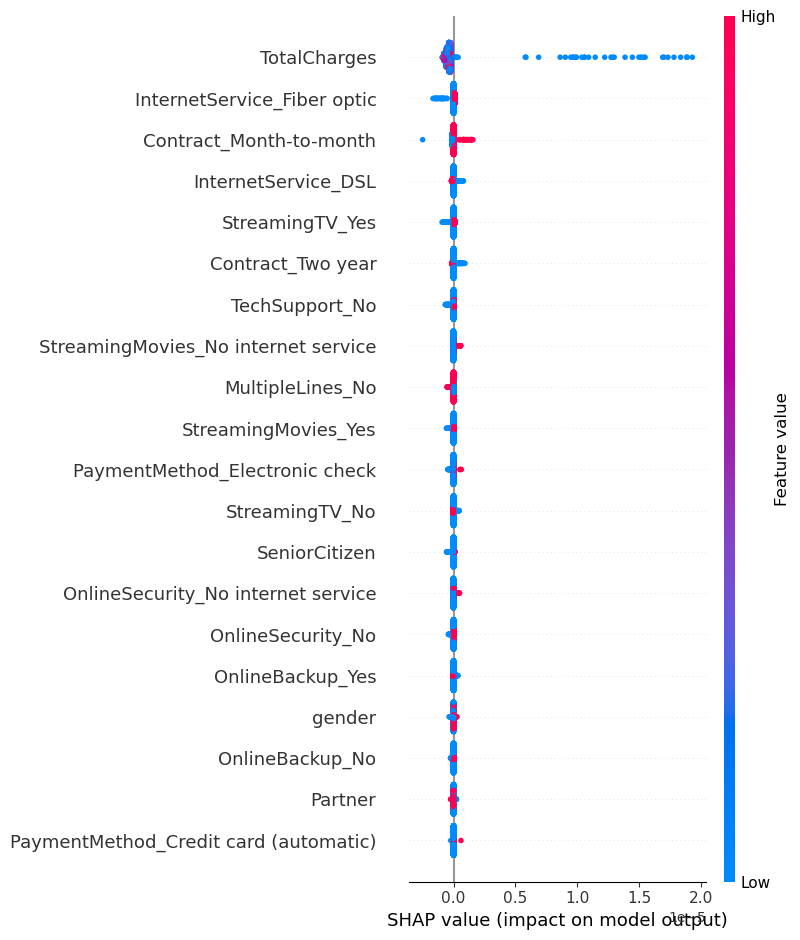

In [274]:
shap.summary_plot(shap_values, X_test_df)

In [275]:
importance = np.abs(shap_values.values).mean(axis=0)

feature_importance = pd.DataFrame({
    "feature": X_test_df.columns,
    "importance": importance
}).sort_values("importance", ascending=False)

top_features = feature_importance.head(15)["feature"]
X_train_reduced = X_train_df[top_features]
X_test_reduced = X_test_df[top_features]